## Notebook for evaluating Li-solvent binding energy

**Created on 10th July, 2024; modified on 14th August, 2024; remodified on 7th January, 2025**

In [1]:
from pymatgen.io.gaussian import GaussianOutput
import pandas as pd
import numpy as np
import os, sys
import glob
import seaborn as sns
from ase.io import read, write
from ase.visualize import view
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw, Descriptors, PandasTools, rdMolDescriptors, Fragments
import thermo
from ase.io import read, write
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
# from electropy.ifg import identify_functional_groups ## Need ifg.py file

In [2]:
%%bash
pwd
ls -ltr

/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/optimization
total 1128
-rw-r--r--   1 riteshk  staff     620 Jul 10 16:21 bind_energy_Li_first.csv
-rw-r--r--   1 riteshk  staff     880 Jul 11 14:51 third_Li_bind_energy.csv
-rw-r--r--@  1 riteshk  staff   26870 Jul 12 09:59 plot_bind_energy_Li_07122024.pdf
-rw-r--r--@  1 riteshk  staff     399 Jul 12 11:43 bind_energy_Li_all.csv
-rw-r--r--@  1 riteshk  staff   30240 Jul 12 11:48 plot_bind_energy_Li_vs_CE_07122024.pdf
drwx------   8 riteshk  staff     256 Jul 14 18:12 LiFSA
-rw-r--r--@  1 riteshk  staff    2016 Aug  5 14:47 frontier_isolated_solv_add_080524.csv
drwx------   4 riteshk  staff     128 Aug  5 14:49 FSA-
-rw-r--r--   1 riteshk  staff    1137 Aug  5 14:52 frontier_isolated_solv_all_080124.csv
-rw-r--r--@  1 riteshk  staff     821 Aug  5 15:00 frontier_isolated_solv_080124.csv
-rw-r--r--@  1 riteshk  staff     805 Aug  5 15:01 frontier_isolated_solv_080524.csv
-rw-r--r--@  1 rit

### Calculate solvent-Li binding energies

#### For first iteration molecules

In [ ]:
# %%bash
# echo "index,pris_energy,bound_energy" > first_Li_bind_energy.csv
# for i in {0..5}
# do
# pris_energy=`grep "E(RB3LYP)" isolated-solv/first_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}'`
# # bound_energy=`grep "E(RB3LYP)" Li-binding/positive_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}'`
# echo "$i,${pris_energy},${bound_energy}" >> energy.csv
# done

In [4]:
out_0_1 = GaussianOutput("Li-bound/1st-iter/first_0_Li+_1.log")
out_0_1.final_energy

-1162.90595494

In [5]:
out_Li = GaussianOutput("Li+/Li+.log")
out_Li.final_energy

-7.45480436517

In [7]:
%%bash
# echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > first_Li_bind_energy.csv
echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > first_Li_bind_energy_081424.csv
li_energy=$(grep "E(RB3LYP)" Li+/Li+.log | tail -1 | awk '{printf "%12.8f\n", $5}')
for i in {0..5}
do
  pris_energy_sum=0
  bound_energy_sum=0
  pris_energy_count=$(ls isolated-solv/1st-iter/first_${i}*.log | wc -l)
  # bound_energy_count=$(ls Li-binding/1st-iter/first_${i}_Li+_*.log | wc -l)
  bound_energy_count=$(ls Li-bound/1st-iter/first_${i}_Li+_*.log | wc -l) ## changed folder name

  pris_energy=$(grep "E(RB3LYP)" isolated-solv/1st-iter/first_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}')

  j=1
  # for bound_file in Li-binding/1st-iter/first_${i}_Li+_*.log
  for bound_file in Li-bound/1st-iter/first_${i}_Li+_*.log
  do
    echo $bound_file
    bound_energy=$(grep "E(RB3LYP)" "$bound_file" | tail -1 | awk '{printf "%12.8f\n", $5}')
    # bound_energy_sum=$(echo "$bound_energy_sum + $bound_energy" | bc)
    bind_energy=$(echo "$bound_energy - $pris_energy - $li_energy" | bc)
    # echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> first_Li_bind_energy.csv
    echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> first_Li_bind_energy_081424.csv ## creating new one on 2024-08-14
    j=$((j+1))
  done
done

Li-bound/1st-iter/first_0_Li+_1.log
Li-bound/1st-iter/first_0_Li+_2.log
Li-bound/1st-iter/first_0_Li+_3.log
Li-bound/1st-iter/first_1_Li+_1.log
Li-bound/1st-iter/first_1_Li+_2.log
Li-bound/1st-iter/first_2_Li+_1.log
Li-bound/1st-iter/first_2_Li+_2.log
Li-bound/1st-iter/first_2_Li+_3.log
Li-bound/1st-iter/first_3_Li+_1.log
Li-bound/1st-iter/first_3_Li+_2.log
Li-bound/1st-iter/first_4_Li+_1.log
Li-bound/1st-iter/first_5_Li+_1.log


In [ ]:
# df_first = pd.read_csv("first_Li_bind_energy.csv")
# df_first

In [9]:
df_first = pd.read_csv("first_Li_bind_energy_081424.csv")
df_first

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-1155.439744,-1162.905955,-0.011407
1,0,2,-1155.439744,-1162.907076,-0.012528
2,0,3,-1155.439744,-1162.900384,-0.005836
3,1,1,-772.035843,-779.509147,-0.018500
4,1,2,-772.035843,-779.505679,-0.015032
5,2,1,-881.695349,-889.164212,-0.014059
6,2,2,-881.695349,-889.161201,-0.011048
7,2,3,-881.695349,-889.150995,-0.000842
8,3,1,-1242.038843,-1249.503443,-0.009795
9,3,2,-1242.038843,-1249.502434,-0.008786


In [10]:
df_first['bind_ener_eV'] = df_first['Li_bind_energy'] * 27.211324570273
df_first

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy,bind_ener_eV
0,0,1,-1155.439744,-1162.905955,-0.011407,-0.310400
1,0,2,-1155.439744,-1162.907076,-0.012528,-0.340908
2,0,3,-1155.439744,-1162.900384,-0.005836,-0.158805
3,1,1,-772.035843,-779.509147,-0.018500,-0.503419
4,1,2,-772.035843,-779.505679,-0.015032,-0.409028
5,2,1,-881.695349,-889.164212,-0.014059,-0.382570
6,2,2,-881.695349,-889.161201,-0.011048,-0.300632
7,2,3,-881.695349,-889.150995,-0.000842,-0.022911
8,3,1,-1242.038843,-1249.503443,-0.009795,-0.266541
9,3,2,-1242.038843,-1249.502434,-0.008786,-0.239076


In [11]:
df_first['mol_index'].duplicated()
# Group by 'mol_index' and find the minimum 'bind_ener_eV' for each group
min_bind_ener_eV_per_mol_index = df_first.groupby('mol_index')['bind_ener_eV'].min().reset_index()

# Display the result
print(min_bind_ener_eV_per_mol_index)

   mol_index  bind_ener_eV
0          0     -0.340908
1          1     -0.503419
2          2     -0.382570
3          3     -0.266541
4          4     -0.275491
5          5     -0.260382


In [12]:
df_first_smiles = pd.read_csv("isolated-solv/list_1st_iter.csv")
df_first_smiles

,smiles,CAS,CE_1M,CE_2M,dissolve,dual_phase
0,COCCOS(=O)(=O)C(F)(F)F,112981-50-7,0.00,0.0,0,0
1,CCCCOCCCl,10503-96-5,14.83,NaN,1,0
2,CS(=O)(=O)OCCCF,372-04-3,97.75,NaN,1,0
3,CCOCCS(=O)(=O)Cl,69371-75-1,74.51,NaN,1,0
4,CCS(=O)(=O)Cl,594-44-5,31.61,NaN,1,0
5,C(CCl)S(=O)(=O)Cl,1622-32-8,6.29,NaN,0,1


,mol_index,config_index,bind_ener_eV,smiles,CE_1M,CE_2M,mol
0,0,2,-0.340908,COCCOS(=O)(=O)C(F)(F)F,0.00,0.0,
1,1,1,-0.503419,CCCCOCCCl,14.83,NaN,
2,2,1,-0.382570,CS(=O)(=O)OCCCF,97.75,NaN,
3,3,1,-0.266541,CCOCCS(=O)(=O)Cl,74.51,NaN,
4,4,1,-0.275491,CCS(=O)(=O)Cl,31.61,NaN,
5,5,1,-0.260382,C(CCl)S(=O)(=O)Cl,6.29,NaN,

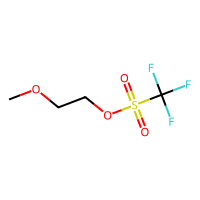
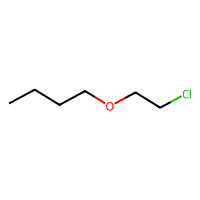
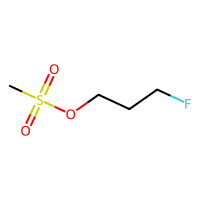
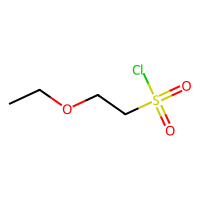
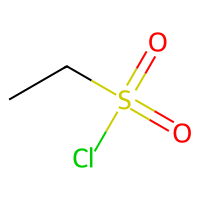
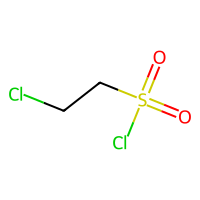

In [13]:
# Find the index of the minimum 'bind_ener_eV' for each 'mol_index'
min_bind_ener_indices = df_first.groupby('mol_index')['bind_ener_eV'].idxmin()

# Use these indices to get the corresponding 'mol_index' and 'config_index'
df_bind_first = df_first.loc[min_bind_ener_indices, ['mol_index', 'config_index', 'bind_ener_eV']]

# Display the result
df_bind_first.reset_index(drop=True, inplace=True)
df_bind_first['smiles'] = df_first_smiles['smiles']
df_bind_first['CE_1M'] = df_first_smiles['CE_1M']
df_bind_first['CE_2M'] = df_first_smiles['CE_2M']
PandasTools.AddMoleculeColumnToFrame(df_bind_first, 'smiles', 'mol')
df_bind_first

In [8]:
df_bind_first.to_csv('bind_energy_Li_first.csv', index=False)

#### For third iteration molecules

In [14]:
%%bash
# echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > third_Li_bind_energy.csv
echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > third_Li_bind_energy_081424.csv
li_energy=$(grep "E(RB3LYP)" Li+/Li+.log | tail -1 | awk '{printf "%12.8f\n", $5}')
for i in {0..8}
do
  pris_energy_sum=0
  bound_energy_sum=0
  pris_energy_count=$(ls isolated-solv/3rd-iter/third_${i}*.log | wc -l)
  # bound_energy_count=$(ls Li-binding/3rd-iter/third_${i}_Li+_*.log | wc -l)
  bound_energy_count=$(ls Li-bound/3rd-iter/third_${i}_Li+_*.log | wc -l)

  pris_energy=$(grep "E(RB3LYP)" isolated-solv/3rd-iter/third_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}')

  j=1
  # for bound_file in Li-binding/3rd-iter/third_${i}_Li+_*.log
  for bound_file in Li-bound/3rd-iter/third_${i}_Li+_*.log
  do
    echo $bound_file
    bound_energy=$(grep "E(RB3LYP)" "$bound_file" | tail -1 | awk '{printf "%12.8f\n", $5}')
    # bound_energy_sum=$(echo "$bound_energy_sum + $bound_energy" | bc)
    bind_energy=$(echo "$bound_energy - $pris_energy - $li_energy" | bc)
    echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> third_Li_bind_energy_081424.csv
    j=$((j+1))
  done
done

Li-bound/3rd-iter/third_0_Li+_1.log
Li-bound/3rd-iter/third_0_Li+_2.log
Li-bound/3rd-iter/third_1_Li+_1.log
Li-bound/3rd-iter/third_1_Li+_2.log
Li-bound/3rd-iter/third_1_Li+_3.log
Li-bound/3rd-iter/third_1_Li+_4.log
Li-bound/3rd-iter/third_2_Li+_1.log
Li-bound/3rd-iter/third_3_Li+_1.log
Li-bound/3rd-iter/third_4_Li+_1.log
Li-bound/3rd-iter/third_4_Li+_2.log
Li-bound/3rd-iter/third_4_Li+_3.log
Li-bound/3rd-iter/third_5_Li+_1.log
Li-bound/3rd-iter/third_5_Li+_2.log
Li-bound/3rd-iter/third_6_Li+_1.log
Li-bound/3rd-iter/third_7_Li+_1.log
Li-bound/3rd-iter/third_7_Li+_2.log
Li-bound/3rd-iter/third_7_Li+_3.log
Li-bound/3rd-iter/third_7_Li+_4.log
Li-bound/3rd-iter/third_8_Li+_1.log


In [15]:
df_third = pd.read_csv("third_Li_bind_energy_081424.csv")
df_third

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-485.720618,-493.183635,-0.008213
1,0,2,-485.720618,-493.189828,-0.014406
2,1,1,-624.355396,-631.823920,-0.013719
3,1,2,-624.355396,-631.812274,-0.002073
4,1,3,-624.355396,-631.814990,-0.004789
5,1,4,-624.355396,-631.811154,-0.000953
6,2,1,-312.412327,-319.880655,-0.013524
7,3,1,-391.072893,-398.545228,-0.017531
8,4,1,-353.643407,-361.104788,-0.006576
9,4,2,-353.643407,-361.103047,-0.004835


In [16]:
df_third['bind_ener_eV'] = df_third['Li_bind_energy'] * 27.211324570273
df_third

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy,bind_ener_eV
0,0,1,-485.720618,-493.183635,-0.008213,-0.223476
1,0,2,-485.720618,-493.189828,-0.014406,-0.392002
2,1,1,-624.355396,-631.823920,-0.013719,-0.373306
3,1,2,-624.355396,-631.812274,-0.002073,-0.056409
4,1,3,-624.355396,-631.814990,-0.004789,-0.130327
5,1,4,-624.355396,-631.811154,-0.000953,-0.025926
6,2,1,-312.412327,-319.880655,-0.013524,-0.368000
7,3,1,-391.072893,-398.545228,-0.017531,-0.477050
8,4,1,-353.643407,-361.104788,-0.006576,-0.178944
9,4,2,-353.643407,-361.103047,-0.004835,-0.131575


In [17]:
df_third_smiles = pd.read_csv("isolated-solv/list_3rd_iter.csv")
df_third_smiles

,smiles,CAS,CE_1M,CE_2M,dissolve,dual_phase
0,CC1(OCC(O1)CF)C,33644-24-5,95.24,95.15,1.0,0.0
1,FC(COC(=O)C(C)(C)C)F,1874200-52-8,78.18,NaN,1.0,0.0
2,CCOCC(C)C,627-02-1,NaN,98.84,1.0,1.0
3,CC(C)COCC(C)C,628-55-7,NaN,NaN,1.0,NaN
4,C(OCF)F,462-51-1,0.00,0.00,0.0,0.0
5,COCC(F)(F)F,460-43-5,NaN,NaN,NaN,NaN
6,CC1OCCCO1,626-68-6,NaN,NaN,NaN,NaN
7,CCCON=O,543-67-9,0.00,0.00,0.0,NaN
8,CCCC(OC)OC,4461-87-4,88.69,NaN,1.0,NaN


,mol_index,config_index,bind_ener_eV,smiles,CE_1M,CE_2M,mol
0,0,2,-0.392002,CC1(OCC(O1)CF)C,95.24,95.15,
1,1,1,-0.373306,FC(COC(=O)C(C)(C)C)F,78.18,NaN,
2,2,1,-0.368000,CCOCC(C)C,NaN,98.84,
3,3,1,-0.477050,CC(C)COCC(C)C,NaN,NaN,
4,4,3,-0.244242,C(OCF)F,0.00,0.00,
5,5,2,-0.317729,COCC(F)(F)F,NaN,NaN,
6,6,1,-0.263886,CC1OCCCO1,NaN,NaN,
7,7,3,-0.227269,CCCON=O,0.00,0.00,
8,8,1,-0.482776,CCCC(OC)OC,88.69,NaN,

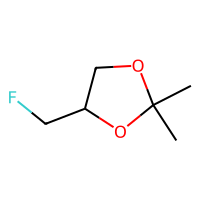
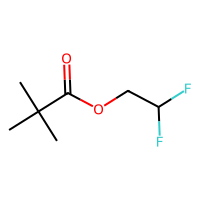
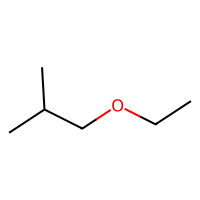
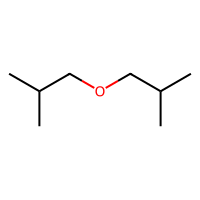
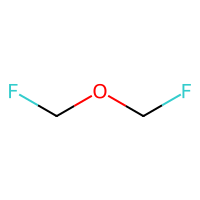
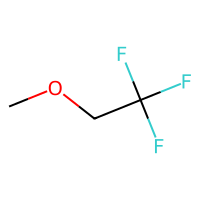
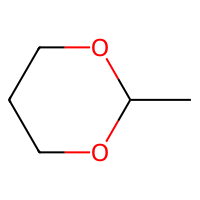
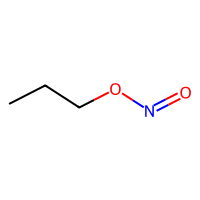
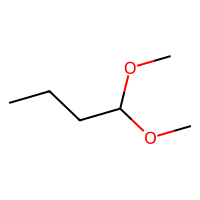

In [18]:
# Find the index of the minimum 'bind_ener_eV' for each 'mol_index'
min_bind_ener_indices = df_third.groupby('mol_index')['bind_ener_eV'].idxmin()

# Use these indices to get the corresponding 'mol_index' and 'config_index'
df_bind_third = df_third.loc[min_bind_ener_indices, ['mol_index', 'config_index', 'bind_ener_eV']]
df_bind_third.reset_index(drop=True, inplace=True)
df_bind_third['smiles'] = df_third_smiles['smiles']
df_bind_third['CE_1M'] = df_third_smiles['CE_1M']
df_bind_third['CE_2M'] = df_third_smiles['CE_2M']
PandasTools.AddMoleculeColumnToFrame(df_bind_third, 'smiles', 'mol')
df_bind_third

In [20]:
df_bind_third.to_csv('bind_energy_Li_third.csv', index=False)

In [19]:
df_all = pd.concat([df_bind_first, df_bind_third], axis=0, ignore_index=True)
df_all

,mol_index,config_index,bind_ener_eV,smiles,CE_1M,CE_2M,mol
0,0,2,-0.340908,COCCOS(=O)(=O)C(F)(F)F,0.00,0.00,<rdkit.Chem.rdchem.Mol object at 0x3311a6900>
1,1,1,-0.503419,CCCCOCCCl,14.83,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311a6430>
2,2,1,-0.382570,CS(=O)(=O)OCCCF,97.75,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311a6970>
3,3,1,-0.266541,CCOCCS(=O)(=O)Cl,74.51,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311a6580>
4,4,1,-0.275491,CCS(=O)(=O)Cl,31.61,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311a6b30>
5,5,1,-0.260382,C(CCl)S(=O)(=O)Cl,6.29,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311a6e40>
6,0,2,-0.392002,CC1(OCC(O1)CF)C,95.24,95.15,<rdkit.Chem.rdchem.Mol object at 0x331122040>
7,1,1,-0.373306,FC(COC(=O)C(C)(C)C)F,78.18,NaN,<rdkit.Chem.rdchem.Mol object at 0x331122f20>
8,2,1,-0.368000,CCOCC(C)C,NaN,98.84,<rdkit.Chem.rdchem.Mol object at 0x3311143c0>
9,3,1,-0.477050,CC(C)COCC(C)C,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x3311140b0>


In [20]:
# df_all.to_csv('bind_energy_Li_all.csv', index=False)
df_all.to_csv('bind_energy_Li_this_work_081424.csv', index=False)

In [2]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118

#### Visualize plot for solvent-Li binding energies (for manuscript) => not keeping in manuscript anymore as trend do not hold

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([<matplotlib.axis.XTick at 0x3039e4580>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14')])

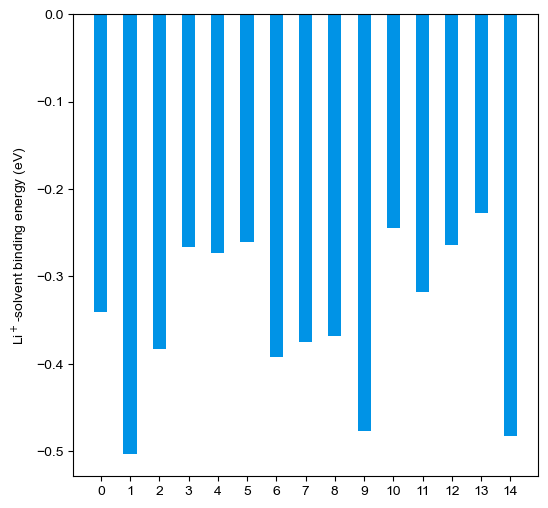

In [28]:
# Set position of bar on X axis
barWidth = 0.45
fig, ax = plt.subplots(figsize=(6,6))
br1 = np.arange(len(df_all),dtype=object)
# br2 = [x + barWidth for x in br1]
# br3 = [x + barWidth for x in br2]
# ax.bar(br1, list(df_all['bind_ener_eV']), width=barWidth, label='MD prediction (RMSE={:.2f})'.format(rmse_md), color=blue)
ax.bar(br1, list(df_all['bind_ener_eV']), width=barWidth, color=blue)
# ax.set_aspect(aspect=4)
plt.legend(frameon=False)
plt.ylabel('Li$^+$-solvent binding energy (eV)')
# plt.xticks([r + barWidth for r in range(len(df))],
#         ['E3F1', 'E4F1', 'E5F1', 'E6F1', 'E3F2', 'E5F2'])
plt.xticks([r for r in range(len(df_all))], list(i for i in range(len(df_all))))
# ax.set_yticks([0.0,0.5,1.0,1.5])
# ax.set_yticklabels([0.0,0.5,1.0,1.5])
# plt.savefig('fig3i.eps', dpi=300)

In [8]:
import matplotlib.font_manager as fm ## this is required to render text-editable plots from matplotlib
plt.rc('font', family='arial')
import matplotlib

matplotlib.use('cairo')
# matplotlib.use('Qt5Agg')
font = fm.FontProperties(family = 'arial')

In [29]:
barWidth = 0.45
fig, ax = plt.subplots(figsize=(6,6))
br1 = np.arange(len(df_all),dtype=object)
# br2 = [x + barWidth for x in br1]
# br3 = [x + barWidth for x in br2]
# ax.bar(br1, list(df_all['bind_ener_eV']), width=barWidth, label='MD prediction (RMSE={:.2f})'.format(rmse_md), color=blue)
ax.bar(br1, list(df_all['bind_ener_eV']), width=barWidth, color=blue)
# ax.set_aspect(aspect=4)
plt.legend(frameon=False)
plt.ylabel('Li$^+$-solvent binding energy (eV)')
# plt.xticks([r + barWidth for r in range(len(df))],
#         ['E3F1', 'E4F1', 'E5F1', 'E6F1', 'E3F2', 'E5F2'])
plt.xticks([r for r in range(len(df_all))], list(i for i in range(len(df_all))))

# plt.show() ## first check plot by uncommenting this line
plt.savefig('plot_bind_energy_Li_07122024.pdf', dpi=300) ## only pdf file is editable

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


#### Visualize plot for just CE (for manuscript): on Dec 11th, 2024

,ID,name,mol_index,config_index,bind_ener_eV,smiles,dissolve,CE_1M,CE_2M,mol
0,1,ESCl,4,1,-0.275491,CCS(=O)(=O)Cl,1,31.61,NaN,
1,2,ClESCl,5,1,-0.260382,C(CCl)S(=O)(=O)Cl,0,0.00,0.00,
2,3,EoESCl,3,1,-0.266541,CCOCCS(=O)(=O)Cl,1,74.51,NaN,
3,4,FPrMS,2,1,-0.382570,CS(=O)(=O)OCCCF,1,97.75,NaN,
4,5,MoESCF3,0,2,-0.340908,COCCOS(=O)(=O)C(F)(F)F,0,0.00,0.00,
5,6,EMP,2,1,-0.368000,CCOCC(C)C,1,NaN,98.84,
6,7,DPE,3,1,-0.477050,CC(C)COCC(C)C,0,0.00,0.00,
7,8,BDMA,8,1,-0.482776,CCCC(OC)OC,1,88.69,NaN,
8,9,MDOX,6,1,-0.263886,CC1OCCCO1,1,NaN,NaN,
9,10,BFME,4,3,-0.244242,C(OCF)F,0,0.00,0.00,

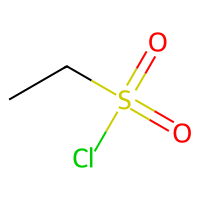
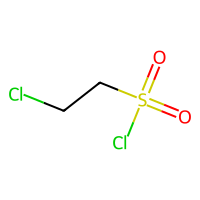
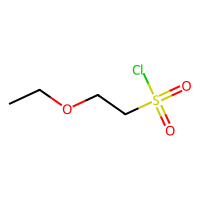
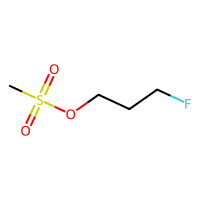
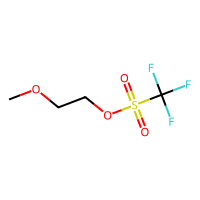
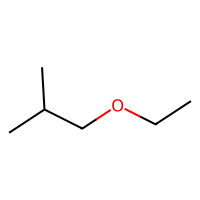
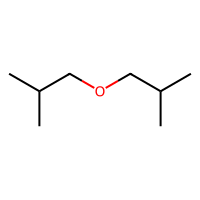
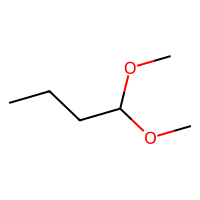
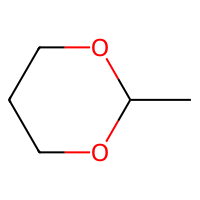
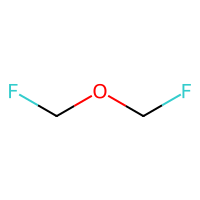
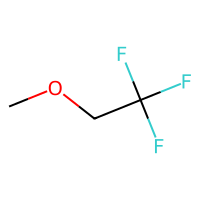
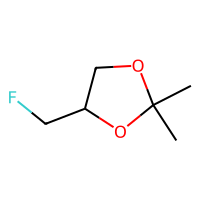
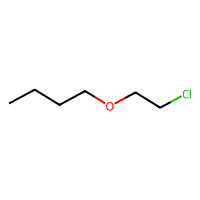
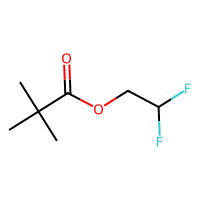
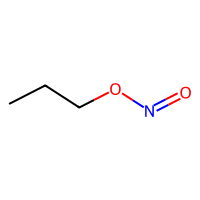

In [3]:
df_all = pd.read_csv('bind_energy_Li_this_work_121124.csv') ## manually edited file??
PandasTools.AddMoleculeColumnToFrame(df_all, 'smiles', 'mol')
df_all

In [6]:
Chem.MolToSmiles(Chem.MolFromSmiles('CC(C)(C)C(=O)OCC(F)F'))
Chem.MolToSmiles(Chem.MolFromSmiles('FC(COC(=O)C(C)(C)C)F'))

'CC(C)(C)C(=O)OCC(F)F'

In [7]:
np.std([29.65,0])
np.mean([29.65,0])
np.mean([43.35,19.87])
np.std([43.35,19.87])

11.74

#### Visualize plot for solvent-Li binding energies vs CE (probably in SI): incomplete not using it

In [2]:
df_all_ = pd.read_csv('bind_energy_Li_this_work_081424.csv') ## removed entries that does not have CE
df_all_

,mol_index,config_index,bind_ener_eV,smiles,CE_1M_2M
0,1,1,-0.503419,CCCCOCCCl,14.83
1,2,1,-0.382570,CS(=O)(=O)OCCCF,97.75
2,3,1,-0.266541,CCOCCS(=O)(=O)Cl,74.51
3,4,1,-0.273112,CCS(=O)(=O)Cl,31.61
4,5,1,-0.260382,C(CCl)S(=O)(=O)Cl,6.29
5,0,2,-0.392002,CC1(OCC(O1)CF)C,95.24
6,1,1,-0.374611,FC(COC(=O)C(C)(C)C)F,78.18
7,2,1,-0.368000,CCOCC(C)C,98.84
8,8,1,-0.482776,CCCC(OC)OC,88.69


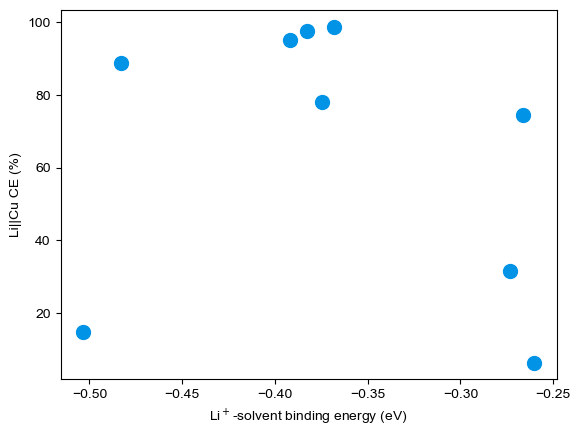

In [7]:
plt.scatter(df_all_['bind_ener_eV'], df_all_['CE_1M_2M'], color=blue, s=100)
plt.xlabel('Li$^+$-solvent binding energy (eV)')
plt.ylabel('Li||Cu CE (%)')
plt.show()

In [9]:
plt.scatter(df_all_['bind_ener_eV'], df_all_['CE_1M_2M'], color=blue, s=100)
plt.xlabel('Li$^+$-solvent binding energy (eV)')
plt.ylabel('Li||Cu CE (%)')
plt.savefig('plot_bind_energy_Li_vs_CE_07122024.pdf', dpi=300) ## only pdf file is editable

#### For OOD molecules from electrolytomics work

In [22]:
%%bash
# echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > ood_Li_bind_energy.csv
echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > ood_Li_bind_energy_081424.csv
li_energy=$(grep "E(RB3LYP)" Li+/Li+.log | tail -1 | awk '{printf "%12.8f\n", $5}')
for i in {0..25}
do
  pris_energy_sum=0
  bound_energy_sum=0
  pris_energy_count=$(ls isolated-solv/lit-in-house/ood_${i}*.log | wc -l)
  bound_energy_count=$(ls Li-bound/lit-in-house/ood_${i}_Li+_*.log | wc -l)

  pris_energy=$(grep "E(RB3LYP)" isolated-solv/lit-in-house/ood_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}')

  j=1 ## gives wrong index for config!!!!
  for bound_file in Li-bound/lit-in-house/ood_${i}_Li+_*.log
  do
    echo $bound_file
    bound_energy=$(grep "E(UB3LYP)" "$bound_file" | tail -1 | awk '{printf "%12.8f\n", $5}')
    # bound_energy_sum=$(echo "$bound_energy_sum + $bound_energy" | bc)
    bind_energy=$(echo "$bound_energy - $pris_energy - $li_energy" | bc)
    # echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> ood_Li_bind_energy.csv
    echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> ood_Li_bind_energy_081424.csv
    j=$((j+1))
  done
done

Li-bound/lit-in-house/ood_0_Li+_1.log


Li-bound/lit-in-house/ood_0_Li+_2.log
Li-bound/lit-in-house/ood_0_Li+_3.log
Li-bound/lit-in-house/ood_0_Li+_4.log
Li-bound/lit-in-house/ood_1_Li+_1.log
Li-bound/lit-in-house/ood_1_Li+_4.log
Li-bound/lit-in-house/ood_1_Li+_5.log
Li-bound/lit-in-house/ood_1_Li+_7.log
Li-bound/lit-in-house/ood_2_Li+_1.log
Li-bound/lit-in-house/ood_2_Li+_2.log
Li-bound/lit-in-house/ood_3_Li+_1.log
Li-bound/lit-in-house/ood_3_Li+_2.log
Li-bound/lit-in-house/ood_3_Li+_3.log
Li-bound/lit-in-house/ood_4_Li+_2.log
Li-bound/lit-in-house/ood_4_Li+_3.log
Li-bound/lit-in-house/ood_5_Li+_1.log
Li-bound/lit-in-house/ood_5_Li+_2.log
Li-bound/lit-in-house/ood_5_Li+_3.log
Li-bound/lit-in-house/ood_6_Li+_1.log
Li-bound/lit-in-house/ood_6_Li+_2.log
Li-bound/lit-in-house/ood_6_Li+_3.log
Li-bound/lit-in-house/ood_7_Li+_1.log
Li-bound/lit-in-house/ood_7_Li+_2.log
Li-bound/lit-in-house/ood_7_Li+_3.log
Li-bound/lit-in-house/ood_8_Li+_1.log
Li-bound/lit-in-house/ood_8_Li+_2.log
Li-bound/lit-in-house/ood_8_Li+_3.log
Li-bound/lit

ls: isolated-solv/lit-in-house/ood_12*.log: No such file or directory
ls: Li-bound/lit-in-house/ood_12_Li+_*.log: No such file or directory
grep: isolated-solv/lit-in-house/ood_12.log: No such file or directory


Li-bound/lit-in-house/ood_12_Li+_*.log


grep: Li-bound/lit-in-house/ood_12_Li+_*.log: No such file or directory
ls: isolated-solv/lit-in-house/ood_13*.log: No such file or directory
ls: Li-bound/lit-in-house/ood_13_Li+_*.log: No such file or directory
grep: isolated-solv/lit-in-house/ood_13.log: No such file or directory


...

Li-bound/lit-in-house/ood_14_Li+_1.log
Li-bound/lit-in-house/ood_14_Li+_2.log
Li-bound/lit-in-house/ood_14_Li+_3.log
Li-bound/lit-in-house/ood_15_Li+_1.log
Li-bound/lit-in-house/ood_15_Li+_3.log
Li-bound/lit-in-house/ood_16_Li+_1.log
Li-bound/lit-in-house/ood_16_Li+_2.log
Li-bound/lit-in-house/ood_16_Li+_3.log
Li-bound/lit-in-house/ood_17_Li+_1.log
Li-bound/lit-in-house/ood_17_Li+_2.log
Li-bound/lit-in-house/ood_18_Li+_1.log
Li-bound/lit-in-house/ood_18_Li+_2.log
Li-bound/lit-in-house/ood_19_Li+_1.log
Li-bound/lit-in-house/ood_19_Li+_2.log
Li-bound/lit-in-house/ood_19_Li+_3.log
Li-bound/lit-in-house/ood_20_Li+_1.log
Li-bound/lit-in-house/ood_20_Li+_2.log


ls: isolated-solv/lit-in-house/ood_21*.log: No such file or directory
ls: Li-bound/lit-in-house/ood_21_Li+_*.log: No such file or directory
grep: isolated-solv/lit-in-house/ood_21.log: No such file or directory


Li-bound/lit-in-house/ood_21_Li+_*.log


grep: Li-bound/lit-in-house/ood_21_Li+_*.log: No such file or directory


Li-bound/lit-in-house/ood_22_Li+_1.log
Li-bound/lit-in-house/ood_23_Li+_1.log
Li-bound/lit-in-house/ood_24_Li+_2.log
Li-bound/lit-in-house/ood_24_Li+_4.log
Li-bound/lit-in-house/ood_24_Li+_5.log
Li-bound/lit-in-house/ood_24_Li+_6.log
Li-bound/lit-in-house/ood_24_Li+_7.log
Li-bound/lit-in-house/ood_25_Li+_1.log
Li-bound/lit-in-house/ood_25_Li+_2.log
Li-bound/lit-in-house/ood_25_Li+_6.log


In [7]:
# df_ood = pd.read_csv("ood_Li_bind_energy.csv")
# df_ood

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-1137.179987,-1144.668394,-0.033602
1,0,2,-1137.179987,-1144.655085,-0.020293
2,1,1,-740.060047,-747.560889,-0.046038
3,1,2,-740.060047,-747.542802,-0.027951
4,2,1,-502.226742,-509.702667,-0.021121
5,3,1,-426.965859,NaN,434.420663
6,4,1,-426.970580,NaN,434.425384
7,5,1,-426.965908,NaN,434.420713
8,6,1,-387.642934,NaN,395.097739
9,7,1,-426.975539,NaN,434.430343


In [23]:
df_ood = pd.read_csv("ood_Li_bind_energy_081424.csv")
df_ood

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-1137.179987,-1144.668394,-0.033602
1,0,2,-1137.179987,-1144.655811,-0.021019
2,0,3,-1137.179987,-1144.645068,-0.010276
3,0,4,-1137.179987,-1144.655814,-0.021023
4,1,1,-740.060047,-747.560889,-0.046038
...,...,...,...,...,...
64,24,4,-786.318180,-793.793444,-0.020460
65,24,5,-786.318180,-793.794038,-0.021054
66,25,1,-832.195265,-839.677572,-0.027503
67,25,2,-832.195265,-839.679064,-0.028995


In [24]:
# df_ood_ = df_ood.loc[df_ood['pris_energy'] < 0 or df_ood['bound_energy'] < 0]
df_ood_ = df_ood.query('pris_energy < 0 and bound_energy < 0')
df_ood_

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-1137.179987,-1144.668394,-0.033602
1,0,2,-1137.179987,-1144.655811,-0.021019
2,0,3,-1137.179987,-1144.645068,-0.010276
3,0,4,-1137.179987,-1144.655814,-0.021023
4,1,1,-740.060047,-747.560889,-0.046038
...,...,...,...,...,...
64,24,4,-786.318180,-793.793444,-0.020460
65,24,5,-786.318180,-793.794038,-0.021054
66,25,1,-832.195265,-839.677572,-0.027503
67,25,2,-832.195265,-839.679064,-0.028995


In [25]:
df_ood_['bind_energy_eV'] = df_ood_['Li_bind_energy'] * 27.211324570273
df_ood_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_38241/1478845314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ood_['bind_energy_eV'] = df_ood_['Li_bind_energy'] * 27.211324570273


,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy,bind_energy_eV
0,0,1,-1137.179987,-1144.668394,-0.033602,-0.914360
1,0,2,-1137.179987,-1144.655811,-0.021019,-0.571968
2,0,3,-1137.179987,-1144.645068,-0.010276,-0.279635
3,0,4,-1137.179987,-1144.655814,-0.021023,-0.572051
4,1,1,-740.060047,-747.560889,-0.046038,-1.252746
...,...,...,...,...,...,...
64,24,4,-786.318180,-793.793444,-0.020460,-0.556739
65,24,5,-786.318180,-793.794038,-0.021054,-0.572909
66,25,1,-832.195265,-839.677572,-0.027503,-0.748392
67,25,2,-832.195265,-839.679064,-0.028995,-0.788985


In [26]:
df_ood_ = df_ood_.loc[df_ood_['bind_energy_eV'] > -2]
df_ood_.reset_index(drop=True, inplace=True)
df_ood_

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy,bind_energy_eV
0,0,1,-1137.179987,-1144.668394,-0.033602,-0.914360
1,0,2,-1137.179987,-1144.655811,-0.021019,-0.571968
2,0,3,-1137.179987,-1144.645068,-0.010276,-0.279635
3,0,4,-1137.179987,-1144.655814,-0.021023,-0.572051
4,1,1,-740.060047,-747.560889,-0.046038,-1.252746
...,...,...,...,...,...,...
61,24,4,-786.318180,-793.793444,-0.020460,-0.556739
62,24,5,-786.318180,-793.794038,-0.021054,-0.572909
63,25,1,-832.195265,-839.677572,-0.027503,-0.748392
64,25,2,-832.195265,-839.679064,-0.028995,-0.788985


In [27]:
min_bind_ener_eV_per_mol_index = df_ood_.groupby('mol_index')['bind_energy_eV'].min().reset_index()

# Display the result
print(min_bind_ener_eV_per_mol_index)

    mol_index  bind_energy_eV
0           0       -0.914360
1           1       -1.252746
2           2       -0.600607
3           3       -0.840103
4           4       -0.929439
5           5       -0.782737
6           6       -0.821595
7           7       -0.834463
8           8       -0.615068
9           9       -0.690531
10         10       -1.273162
11         11       -0.438482
12         14       -0.283728
13         15       -0.499036
14         16       -0.791355
15         17       -0.564584
16         18       -0.388000
17         19       -0.403266
18         20       -0.531203
19         22       -0.507169
20         23       -0.470130
21         24       -0.608416
22         25       -0.788985


In [28]:
min_bind_ener_indices = df_ood_.groupby('mol_index')['bind_energy_eV'].idxmin()

# Use these indices to get the corresponding 'mol_index' and 'config_index'
df_bind_ood = df_ood_.loc[min_bind_ener_indices, ['mol_index', 'config_index', 'bind_energy_eV']]
df_bind_ood.reset_index(drop=True, inplace=True)
df_bind_ood

,mol_index,config_index,bind_energy_eV
0,0,1,-0.914360
1,1,1,-1.252746
2,2,2,-0.600607
3,3,1,-0.840103
4,4,1,-0.929439
5,5,1,-0.782737
6,6,2,-0.821595
7,7,2,-0.834463
8,8,2,-0.615068
9,9,1,-0.690531


In [29]:
# df_bind_ood.to_csv('bind_energy_Li_ood.csv', index=False)
df_bind_ood.to_csv('bind_energy_Li_ood_081424.csv', index=False)

#### For experimentally tested molecules from electrolytomics work & SOTA

In [39]:
%%bash
echo "mol_index,config_index,pris_energy,bound_energy,Li_bind_energy" > sota_Li_bind_energy_081424.csv
li_energy=$(grep "E(RB3LYP)" Li+/Li+.log | tail -1 | awk '{printf "%12.8f\n", $5}')
for i in {0..10}
do
  pris_energy_sum=0
  bound_energy_sum=0
  pris_energy_count=$(ls isolated-solv/sota_expt_omics/sota_${i}*.log | wc -l)
  bound_energy_count=$(ls Li-bound/sota_expt_omics/sota_${i}_Li+_*.log | wc -l)

  pris_energy=$(grep "E(RB3LYP)" isolated-solv/sota_expt_omics/sota_${i}.log | tail -1 | awk '{printf "%12.8f\n", $5}')

  j=1
  for bound_file in Li-bound/sota_expt_omics/sota_${i}_Li+_*.log
  do
    echo $bound_file
    bound_energy=$(grep "E(UB3LYP)" "$bound_file" | tail -1 | awk '{printf "%12.8f\n", $5}')
    # bound_energy_sum=$(echo "$bound_energy_sum + $bound_energy" | bc)
    bind_energy=$(echo "$bound_energy - $pris_energy - $li_energy" | bc)
    echo "$i,$j,$pris_energy,$bound_energy,$bind_energy" >> sota_Li_bind_energy_081424.csv
    j=$((j+1))
  done
done

Li-bound/sota_expt_omics/sota_0_Li+_1.log
Li-bound/sota_expt_omics/sota_0_Li+_2.log
Li-bound/sota_expt_omics/sota_0_Li+_3.log


ls: Li-bound/sota_expt_omics/sota_1_Li+_*.log: No such file or directory
grep: isolated-solv/sota_expt_omics/sota_1.log: No such file or directory


Li-bound/sota_expt_omics/sota_1_Li+_*.log


grep: Li-bound/sota_expt_omics/sota_1_Li+_*.log: No such file or directory


Li-bound/sota_expt_omics/sota_2_Li+_1.log
Li-bound/sota_expt_omics/sota_2_Li+_2.log
Li-bound/sota_expt_omics/sota_2_Li+_3.log
Li-bound/sota_expt_omics/sota_2_Li+_4.log
Li-bound/sota_expt_omics/sota_2_Li+_5.log
Li-bound/sota_expt_omics/sota_2_Li+_6.log
Li-bound/sota_expt_omics/sota_2_Li+_7.log


...

Li-bound/sota_expt_omics/sota_4_Li+_1.log
Li-bound/sota_expt_omics/sota_4_Li+_2.log
Li-bound/sota_expt_omics/sota_5_Li+_1.log
Li-bound/sota_expt_omics/sota_5_Li+_2.log
Li-bound/sota_expt_omics/sota_5_Li+_3.log


ls: isolated-solv/sota_expt_omics/sota_6*.log: No such file or directory
ls: Li-bound/sota_expt_omics/sota_6_Li+_*.log: No such file or directory
grep: isolated-solv/sota_expt_omics/sota_6.log: No such file or directory


Li-bound/sota_expt_omics/sota_6_Li+_*.log


grep: Li-bound/sota_expt_omics/sota_6_Li+_*.log: No such file or directory


Li-bound/sota_expt_omics/sota_7_Li+_1.log
Li-bound/sota_expt_omics/sota_7_Li+_2.log
Li-bound/sota_expt_omics/sota_7_Li+_3.log
Li-bound/sota_expt_omics/sota_7_Li+_4.log
Li-bound/sota_expt_omics/sota_8_Li+_1.log
Li-bound/sota_expt_omics/sota_8_Li+_2.log
Li-bound/sota_expt_omics/sota_8_Li+_3.log
Li-bound/sota_expt_omics/sota_8_Li+_4.log
Li-bound/sota_expt_omics/sota_8_Li+_5.log
Li-bound/sota_expt_omics/sota_9_Li+_1.log
Li-bound/sota_expt_omics/sota_9_Li+_2.log
Li-bound/sota_expt_omics/sota_9_Li+_3.log
Li-bound/sota_expt_omics/sota_9_Li+_4.log
Li-bound/sota_expt_omics/sota_9_Li+_5.log
Li-bound/sota_expt_omics/sota_9_Li+_6.log
Li-bound/sota_expt_omics/sota_10_Li+_1.log
Li-bound/sota_expt_omics/sota_10_Li+_2.log


In [40]:
df_sota = pd.read_csv("sota_Li_bind_energy_081424.csv")
df_sota

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-366.548744,-374.028222,-0.024674
1,0,2,-366.548744,-374.024441,-0.020892
2,0,3,-366.548744,-374.027401,-0.023852
3,1,1,NaN,NaN,-7.454804
4,2,1,-881.687283,-889.157061,-0.014973
5,2,2,-881.687283,-889.161417,-0.019329
6,2,3,-881.687283,-889.161722,-0.019635
7,2,4,-881.687283,-889.160430,-0.018342
8,2,5,-881.687283,-889.153588,-0.011500
9,2,6,-881.687283,-889.152495,-0.010408


In [41]:
df_sota_ = df_sota.query('pris_energy < 0 and bound_energy < 0')
df_sota_

,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy
0,0,1,-366.548744,-374.028222,-0.024674
1,0,2,-366.548744,-374.024441,-0.020892
2,0,3,-366.548744,-374.027401,-0.023852
4,2,1,-881.687283,-889.157061,-0.014973
5,2,2,-881.687283,-889.161417,-0.019329
6,2,3,-881.687283,-889.161722,-0.019635
7,2,4,-881.687283,-889.160430,-0.018342
8,2,5,-881.687283,-889.153588,-0.011500
9,2,6,-881.687283,-889.152495,-0.010408
10,2,7,-881.687283,-889.162381,-0.020294


In [42]:
df_sota_['bind_energy_eV'] = df_sota_['Li_bind_energy'] * 27.211324570273
df_sota_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_38241/2956081950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sota_['bind_energy_eV'] = df_sota_['Li_bind_energy'] * 27.211324570273


,mol_index,config_index,pris_energy,bound_energy,Li_bind_energy,bind_energy_eV
0,0,1,-366.548744,-374.028222,-0.024674,-0.671414
1,0,2,-366.548744,-374.024441,-0.020892,-0.568511
2,0,3,-366.548744,-374.027401,-0.023852,-0.649057
4,2,1,-881.687283,-889.157061,-0.014973,-0.407430
5,2,2,-881.687283,-889.161417,-0.019329,-0.525980
6,2,3,-881.687283,-889.161722,-0.019635,-0.534285
7,2,4,-881.687283,-889.160430,-0.018342,-0.499111
8,2,5,-881.687283,-889.153588,-0.011500,-0.312935
9,2,6,-881.687283,-889.152495,-0.010408,-0.283202
10,2,7,-881.687283,-889.162381,-0.020294,-0.552219


In [43]:
min_bind_ener_eV_per_mol_index = df_sota_.groupby('mol_index')['bind_energy_eV'].min().reset_index()

# Display the result
print(min_bind_ener_eV_per_mol_index)

   mol_index  bind_energy_eV
0          0       -0.671414
1          2       -0.552219
2          4       -0.258610
3          5       -0.276517
4          7       -0.351585
5          8       -0.675801
6          9       -0.598655
7         10       -0.874547


In [44]:
min_bind_ener_indices = df_sota_.groupby('mol_index')['bind_energy_eV'].idxmin()

# Use these indices to get the corresponding 'mol_index' and 'config_index'
df_bind_sota = df_sota_.loc[min_bind_ener_indices, ['mol_index', 'config_index', 'bind_energy_eV']]
df_bind_sota.reset_index(drop=True, inplace=True)
df_bind_sota

,mol_index,config_index,bind_energy_eV
0,0,1,-0.671414
1,2,7,-0.552219
2,4,2,-0.258610
3,5,3,-0.276517
4,7,2,-0.351585
5,8,1,-0.675801
6,9,1,-0.598655
7,10,1,-0.874547


In [45]:
df_bind_sota.to_csv('bind_energy_Li_sota_081424.csv', index=False)

In [38]:
bind_ener_li_fsa = -0.03138850483 * 27.211324570273
bind_ener_li_fsa

-0.8541227927047117

#### Visualize plot for all: binding energy

In [46]:
# df_1 = pd.read_csv('lumo_bind_vs_ce_080524.csv')
df_1 = pd.read_csv('lumo_bind_vs_ce_081424.csv')
df_1

,Compound_id,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV
0,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0,-0.503419
1,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0,-0.382570
2,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0,-0.266541
3,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0,-0.275491
4,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0,-0.260382
5,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0,-0.392002
6,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0,-0.373306
7,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0,-0.368000
8,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0,-0.482776
9,ood_0,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360


In [47]:
df_1_uniq = df_1.loc[df_1['bind_ener_eV'] < 0]
df_1_uniq

,Compound_id,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV
0,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0,-0.503419
1,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0,-0.382570
2,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0,-0.266541
3,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0,-0.275491
4,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0,-0.260382
5,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0,-0.392002
6,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0,-0.373306
7,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0,-0.368000
8,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0,-0.482776
9,ood_0,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360


In [53]:
cols = df_1_uniq.columns
# classes = {'Carbonate':[], 'Sulfone':[], 'Ether':[], "Esters":[], "Nitriles":[], "Aromatic":[], "Others":[]}
classes = {"Carbonate":[], "Sulfone":[], "Ether":[], "Ester":[], "Nitrile":[], "Sulfoxide":[], "Sulfonyl fluoride":[], "Sulfonyl chloride":[],
           "Sulfonate ester":[], "Amine":[], "Amide":[], "Nitro":[], "Ketone":[], "Anhydride":[], "Imide":[], "Silyl ether":[], "Others":[]}
class_arr = []
for i in range(len(df_1_uniq)):
        if type(df_1_uniq['smiles'][i]) == float:
            continue
        else:
            mol = Chem.MolFromSmiles(df_1_uniq['smiles'][i])
            # if rdMolDescriptors.CalcNumAromaticRings(mol) >= 1:
            #     classes['Aromatic'].append(df_1_uniq['smiles'][i])
            if thermo.is_anhydride(mol) == True:
                classes['Anhydride'].append(df_1_uniq['smiles'][i])
                class_arr.append('Anhydride')
            elif thermo.is_sulfonate_ester(mol) == True:
                classes['Sulfonate ester'].append(df_1_uniq['smiles'][i])
                class_arr.append('Sulfonate ester')
            elif "S(=O)(=O)Cl" in df_1_uniq['smiles'][i]:
                classes['Sulfonyl chloride'].append(df_1_uniq['smiles'][i])
                class_arr.append('Sulfonyl chloride')
            elif "S(=O)(=O)F" in df_1_uniq['smiles'][i]:
                classes['Sulfonyl fluoride'].append(df_1_uniq['smiles'][i])
                class_arr.append('Sulfonyl fluoride')
            elif Fragments.fr_sulfone(mol) >= 1: ## calculates only actual sulfones
                classes['Sulfone'].append(df_1_uniq['smiles'][i])
                class_arr.append('Sulfone')
            elif thermo.is_sulfoxide(mol) == True:
                classes['Sulfoxide'].append(df_1_uniq['smiles'][i])
                class_arr.append('Sulfoxide')
            # elif check_carbonate(mol) == True:
            elif thermo.is_carbonate(mol) == True:
                classes['Carbonate'].append(df_1_uniq['smiles'][i])
                class_arr.append('Carbonate')
            elif Fragments.fr_ester(mol) >= 1:
                classes['Ester'].append(df_1_uniq['smiles'][i])
                class_arr.append('Ester')
            elif Fragments.fr_nitrile(mol) >= 1:
                classes['Nitrile'].append(df_1_uniq['smiles'][i])
                class_arr.append('Nitrile')
            elif Fragments.fr_ether(mol) >= 1:
                classes['Ether'].append(df_1_uniq['smiles'][i])
                class_arr.append('Ether')
            elif thermo.is_ketone(mol) == True:
                classes['Ketone'].append(df_1_uniq['smiles'][i])
                class_arr.append('Ketone')
            elif thermo.is_amide(mol) == True:
                classes['Amide'].append(df_1_uniq['smiles'][i])
                class_arr.append('Amide')
            elif thermo.is_tertiary_amine(mol) == True:
                classes['Amine'].append(df_1_uniq['smiles'][i])
                class_arr.append('Amine')
            elif thermo.is_nitro(mol) == True:
                classes['Nitro'].append(df_1_uniq['smiles'][i])
                class_arr.append('Nitro')
            elif thermo.is_imide(mol) == True:
                classes['Imide'].append(df_1_uniq['smiles'][i])
                class_arr.append('Imide')
            elif thermo.is_silyl_ether(mol) == True:
                classes['Silyl ether'].append(df_1_uniq['smiles'][i])
                class_arr.append('Silyl ether')
            else:
                classes['Others'].append(df_1_uniq['smiles'][i])
                class_arr.append('Others')

In [54]:
df_1_uniq['class'] = class_arr
df_1_uniq

,Compound_id,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,dissolve,database,database_,bind_ener_eV,class
0,first_1,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148300,1.0,1.0,this_work,0,-0.503419,Ether
1,first_2,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.977500,1.0,1.0,this_work,0,-0.382570,Sulfonate ester
2,first_3,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.745100,1.0,1.0,this_work,0,-0.266541,Sulfonyl chloride
3,first_4,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,1.0,this_work,0,-0.275491,Sulfonyl chloride
4,first_5,C(CCl)S(=O)(=O)Cl,-8.592248,-2.823447,5.768801,0.062900,1.0,1.0,this_work,0,-0.260382,Sulfonyl chloride
5,third_0,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,1.0,this_work,0,-0.392002,Ether
6,third_1,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,1.0,this_work,0,-0.373306,Ester
7,third_2,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,1.0,this_work,0,-0.368000,Ether
8,third_8,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,1.0,this_work,0,-0.482776,Ether
9,ood_0,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,0.991411,0.991411,1.0,1.0,ood,2,-0.914360,Ether


In [50]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
colors = [blue, orange, purple, anvil, green]

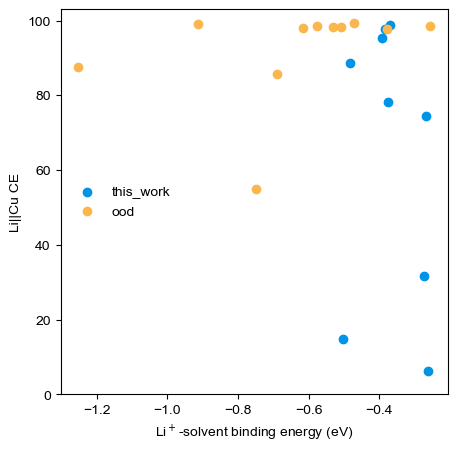

In [25]:
# # Get unique values from the 'database' column
# unique_databases = df_1_uniq['database'].unique()

# fig, ax = plt.subplots(figsize=(5, 5))
# # Loop through each unique value and create a scatter plot
# c = 0
# for database in unique_databases:
#     subset = df_1_uniq[df_1_uniq['database'] == database]
#     ax.scatter(subset['bind_ener_eV'], 100*subset['CE'], label=database, color=colors[c])  # Replace 'x_column' and 'y_column' with actual column names
#     c += 1
# # plt.title(f'Scatter Plot for {database}')
# # ax.vlines(x=-0.328441, ymin=0, ymax=103, color='red', linestyle='--')
# ax.set_xlabel('Li$^+$-solvent binding energy (eV)')  # Replace with actual label
# ax.set_ylabel('Li||Cu CE')  # Replace with actual label
# ax.set_ylim(0, 103)
# plt.legend(frameon=False, loc='center left')
# plt.show()

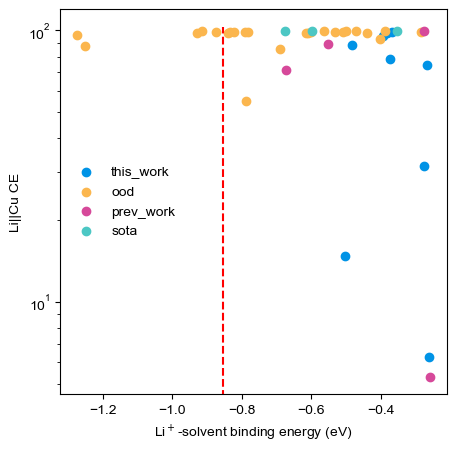

In [56]:
# Get unique values from the 'database' column
unique_databases = df_1_uniq['database'][:-1].unique()

fig, ax = plt.subplots(figsize=(5, 5))
# Loop through each unique value and create a scatter plot
c = 0
for database in unique_databases:
    subset = df_1_uniq[df_1_uniq['database'] == database]
    ax.scatter(subset['bind_ener_eV'], 100*subset['CE'], label=database, color=colors[c])  # Replace 'x_column' and 'y_column' with actual column names
    c += 1
# plt.title(f'Scatter Plot for {database}')
# ax.vlines(x=-0.328441, ymin=0, ymax=103, color='red', linestyle='--')
ax.vlines(x=df_1_uniq['bind_ener_eV'][-1:], ymin=0, ymax=103, color='red', linestyle='--')
ax.set_xlabel('Li$^+$-solvent binding energy (eV)')  # Replace with actual label
ax.set_ylabel('Li||Cu CE')  # Replace with actual label
# ax.set_ylim(0, 103)
ax.set_yscale('log')
plt.legend(frameon=False, loc='center left')
plt.show()

In [55]:
df_1_uniq.to_csv('lumo_bind_vs_ce_class_081424.csv', index=False)

### DFT-based plot visualzations (ignore older ones)

#### Solvent-Li+ binding energy vs salt solubility (for 15 molecules tested in this work)

In [3]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118

In [4]:
df_bind_this_work = pd.read_csv('CE_bind_energy_Li_010225.csv') ## manually edited file
df_bind_this_work

,ID,name,mol_index,config_index,bind_ener_eV,smiles,dissolve,CE_2M,Aurbach_CE_avg,Aurbach_CE_error
0,1,ESCl,4,1,-0.275491,CCS(=O)(=O)Cl,1,NaN,31.610,0.00
1,2,ClESCl,5,1,-0.260382,C(CCl)S(=O)(=O)Cl,0,0.00,0.000,0.00
2,3,EoESCl,3,1,-0.266541,CCOCCS(=O)(=O)Cl,1,NaN,0.000,0.00
3,4,FPrMS,2,1,-0.382570,CS(=O)(=O)OCCCF,1,NaN,81.130,7.70
4,5,MoESCF3,0,2,-0.340908,COCCOS(=O)(=O)C(F)(F)F,0,0.00,0.000,0.00
5,6,EMP,2,1,-0.368000,CCOCC(C)C,1,98.84,98.840,0.15
6,7,DPE,3,1,-0.477050,CC(C)COCC(C)C,0,0.00,0.000,0.00
7,8,BDMA,8,1,-0.482776,CCCC(OC)OC,1,NaN,88.690,2.19
8,9,MDOX,6,1,-0.263886,CC1OCCCO1,1,NaN,96.090,0.11
9,10,BFME,4,3,-0.244242,C(OCF)F,0,0.00,0.000,0.00


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


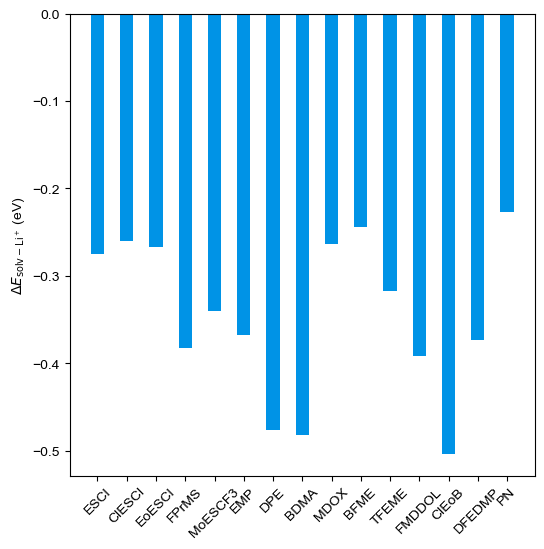

In [14]:
# Set position of bar on X axis
barWidth = 0.45
fig, ax = plt.subplots(figsize=(6,6))
br1 = np.arange(len(df_bind_this_work),dtype=object)
# br2 = [x + barWidth for x in br1]
# br3 = [x + barWidth for x in br2]
# ax.bar(br1, list(df_all['bind_ener_eV']), width=barWidth, label='MD prediction (RMSE={:.2f})'.format(rmse_md), color=blue)
ax.bar(br1, list(df_bind_this_work['bind_ener_eV']), width=barWidth, color=blue)
# ax.set_aspect(aspect=4)
plt.legend(frameon=False)
plt.ylabel('$\Delta E_{\mathrm{solv-Li^+}}$ (eV)')
# plt.xticks([r for r in range(len(df_bind_this_work))], list(i for i in range(1, len(df_bind_this_work)+1)))
plt.xticks([r for r in range(len(df_bind_this_work))], list(df_bind_this_work['name']), rotation=45)
# ax.set_yticks([0.0,0.5,1.0,1.5])
# ax.set_yticklabels([0.0,0.5,1.0,1.5])
plt.savefig('plot_bind_energy_solubility_fig_Sx.eps', dpi=300)

#### Curating data

In [17]:
df_bind_lumo_all = pd.read_csv('CE_bind_energy_LUMO_all_010725.csv') ## edited manually
df_bind_lumo_all['std_smiles'] = df_bind_lumo_all['smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
df_bind_lumo_all

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles
0,first_1,1,13.0,ClEoB,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148250,1.0,this_work,0,-0.503419,Ether,CCCCOCCCl
1,first_2,1,4.0,FPrMS,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.811300,1.0,this_work,0,-0.382570,Sulfonate ester,CS(=O)(=O)OCCCF
2,first_3,1,3.0,EoESCl,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.000000,1.0,this_work,0,-0.266541,Sulfonyl chloride,CCOCCS(=O)(=O)Cl
3,first_4,1,1.0,ESCl,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,this_work,0,-0.275491,Sulfonyl chloride,CCS(=O)(=O)Cl
4,third_0,2,12.0,FMDDOL,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,this_work,0,-0.392002,Ether,CC1(C)OCC(CF)O1
5,third_1,1,14.0,DFEDMP,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,this_work,0,-0.373306,Ester,CC(C)(C)C(=O)OCC(F)F
6,third_2,1,6.0,EMP,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,this_work,0,-0.368000,Ether,CCOCC(C)C
7,third_6,1,9.0,MDOX,CC1OCCCO1,-7.162293,-0.168982,6.993310,0.960900,1.0,this_work,0,-0.263886,Ether,CC1OCCCO1
8,third_8,1,8.0,BDMA,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,this_work,0,-0.482776,Ether,CCCC(OC)OC
9,ood_0,1,NaN,NaN,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,NaN,0.991411,1.0,ood,2,-0.914360,Ether,FC(F)(F)COCCOCCOCC(F)(F)F


In [16]:
def ether_exlc_anhydride(mol):
    if thermo.is_anhydride(mol) == False and thermo.is_carbonate(mol) == False and thermo.is_carbamate(mol) == False:
        if Fragments.fr_ether(mol) >= 1 and Fragments.fr_ether(mol) > Fragments.fr_ester(mol):
            return True
    elif thermo.is_anhydride(mol) == True and thermo.is_carbonate(mol) == False and thermo.is_carbamate(mol) == False:
        if Fragments.fr_ether(mol) > 1 and Fragments.fr_ether(mol) > Fragments.fr_ester(mol):
            return True 
    elif thermo.is_carbonate(mol) == True:
        if Fragments.fr_ether(mol) >= 1 and Fragments.fr_ether(mol) < Fragments.fr_C_O(mol):
            return True
    else:
        return False

def amide_excl_imide(mol):
    if Fragments.fr_imide(mol) == 0 and thermo.is_carbamate(mol) == False:
        if Fragments.fr_amide(mol) >= 1:
            return True
    elif Fragments.fr_imide(mol) >= 1 and thermo.is_carbamate(mol) == False:
        if Fragments.fr_amide(mol) >= 1 and Fragments.fr_amide(mol) > 2 * Fragments.fr_imide(mol):
            return True
    elif Fragments.fr_imide(mol) == 0 and thermo.is_carbamate(mol) == True:
        # print("found carbamate & amide")
        if Fragments.fr_amide(mol) > 1:
            return True
        elif Fragments.fr_amide(mol) == 1:   
            return False
    elif Fragments.fr_imide(mol) >= 1 and thermo.is_carbamate(mol) == True:
        if Fragments.fr_amide(mol) > 1 and Fragments.fr_amide(mol) > 2 * Fragments.fr_imide(mol):
            return True

def ester_exlc_anhydride(mol):
    if thermo.is_anhydride(mol) == False:
        if Fragments.fr_ester(mol) >= 1:
            return True
    elif thermo.is_anhydride(mol) == True:
        if Fragments.fr_ester(mol) > 1:
            return True 
    else:
        return False

def detect_phosphite(mol):
    functional_group = Chem.MolFromSmarts('[P;D3](-[#8]-*)(-[#8]-*)-[#8]-*') ## does not detect phosphate
    match = mol.GetSubstructMatches(functional_group)
    if len(match) > 0:
        return True
    else:
        return False

def calc_func_grp_frac(df_curated, smiles_col):
    classes = {"Carbonate":[], "Sulfone":[], "Ether":[], "Ester":[], "Sulfoxide":[], "Sulfonyl fluoride":[], "Sulfonyl chloride":[],
            "Sulfonate ester":[], "Amine":[], "Amide":[], "Nitro":[], "Ketone":[], "Anhydride":[], "Imide":[], "Silyl ether":[], 
            "Phosphate": [], "Phosphite": [], "Sulfonamide": [], "Carbamate": [], "Nitrile": [], "Others":[]}
    class_arr = []
    for i in range(len(df_curated)):
        if type(df_curated[smiles_col][i]) == float:
            continue
        else:
            mol = Chem.MolFromSmiles(df_curated[smiles_col][i])
            entry_classes = []
            if thermo.is_anhydride(mol):
                classes['Anhydride'].append(df_curated[smiles_col][i])
                entry_classes.append('Anhydride')
            if thermo.is_sulfonate_ester(mol):
                classes['Sulfonate ester'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfonate ester')
            if "S(=O)(=O)Cl" in df_curated[smiles_col][i] and not thermo.is_sulfonate_ester(mol):
                classes['Sulfonyl chloride'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfonyl chloride')
            if "S(=O)(=O)F" in df_curated[smiles_col][i] and not thermo.is_sulfonate_ester(mol):
                classes['Sulfonyl fluoride'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfonyl fluoride')
            if Fragments.fr_sulfone(mol) >= 1:
                classes['Sulfone'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfone')
            if thermo.is_sulfoxide(mol):
                classes['Sulfoxide'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfoxide')
            if thermo.is_carbonate(mol):
                classes['Carbonate'].append(df_curated[smiles_col][i])
                entry_classes.append('Carbonate')
            if ester_exlc_anhydride(mol) == True:
                classes['Ester'].append(df_curated[smiles_col][i])
                entry_classes.append('Ester')
            if Fragments.fr_nitrile(mol) >= 1: ## nitrile not present in this dataset
                classes['Nitrile'].append(df_curated[smiles_col][i])
                entry_classes.append('Nitrile')
            if ether_exlc_anhydride(mol) == True:
                classes['Ether'].append(df_curated[smiles_col][i])
                entry_classes.append('Ether')
            if thermo.is_ketone(mol):
                classes['Ketone'].append(df_curated[smiles_col][i])
                entry_classes.append('Ketone')
            if amide_excl_imide(mol) == True:
                classes['Amide'].append(df_curated[smiles_col][i])
                entry_classes.append('Amide')
            # Check sulfonamide first
            has_sulfonamide = Fragments.fr_sulfonamd(mol) >= 1
            if has_sulfonamide:
                classes['Sulfonamide'].append(df_curated[smiles_col][i])
                entry_classes.append('Sulfonamide')
            # Check for amine only if not a sulfonamide
            elif thermo.is_tertiary_amine(mol) and Fragments.fr_NH0(mol) > (Fragments.fr_amide(mol) + Fragments.fr_nitrile(mol)):
                classes['Amine'].append(df_curated[smiles_col][i]) 
                entry_classes.append('Amine')
            if thermo.is_nitro(mol):
                classes['Nitro'].append(df_curated[smiles_col][i])
                entry_classes.append('Nitro')
            # if thermo.is_imide(mol):
            if Fragments.fr_imide(mol):
                classes['Imide'].append(df_curated[smiles_col][i])
                entry_classes.append('Imide')
            if thermo.is_silyl_ether(mol):
                classes['Silyl ether'].append(df_curated[smiles_col][i])
                entry_classes.append('Silyl ether')
            if Fragments.fr_phos_ester(mol) >= 1:
                classes['Phosphate'].append(df_curated[smiles_col][i])
                entry_classes.append('Phosphate')
            if detect_phosphite(mol):
                classes['Phosphite'].append(df_curated[smiles_col][i])
                entry_classes.append('Phosphite')
            if thermo.is_carbamate(mol):
                classes['Carbamate'].append(df_curated[smiles_col][i])
                entry_classes.append('Carbamate')
            if not entry_classes:
                classes['Others'].append(df_curated[smiles_col][i])
                entry_classes.append('Others')
            class_arr.append(entry_classes)
    df_curated['class'] = class_arr
    return df_curated, classes, class_arr

In [18]:
df_bind_lumo_all_, classes, class_arr = calc_func_grp_frac(df_bind_lumo_all, 'std_smiles')
df_bind_lumo_all_

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles
0,first_1,1,13.0,ClEoB,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148250,1.0,this_work,0,-0.503419,[Ether],CCCCOCCCl
1,first_2,1,4.0,FPrMS,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.811300,1.0,this_work,0,-0.382570,[Sulfonate ester],CS(=O)(=O)OCCCF
2,first_3,1,3.0,EoESCl,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.000000,1.0,this_work,0,-0.266541,"[Sulfonyl chloride, Ether]",CCOCCS(=O)(=O)Cl
3,first_4,1,1.0,ESCl,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,this_work,0,-0.275491,[Sulfonyl chloride],CCS(=O)(=O)Cl
4,third_0,2,12.0,FMDDOL,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,this_work,0,-0.392002,[Ether],CC1(C)OCC(CF)O1
5,third_1,1,14.0,DFEDMP,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,this_work,0,-0.373306,[Ester],CC(C)(C)C(=O)OCC(F)F
6,third_2,1,6.0,EMP,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,this_work,0,-0.368000,[Ether],CCOCC(C)C
7,third_6,1,9.0,MDOX,CC1OCCCO1,-7.162293,-0.168982,6.993310,0.960900,1.0,this_work,0,-0.263886,[Ether],CC1OCCCO1
8,third_8,1,8.0,BDMA,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,this_work,0,-0.482776,[Ether],CCCC(OC)OC
9,ood_0,1,NaN,NaN,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,NaN,0.991411,1.0,ood,2,-0.914360,[Ether],FC(F)(F)COCCOCCOCC(F)(F)F


In [26]:
df_bind_lumo_all_['class'].value_counts()

class
[Ether]                       25
[Sulfonate ester]              3
[Silyl ether]                  3
[Sulfonyl fluoride]            2
[Sulfonyl chloride, Ether]     1
[Sulfonyl chloride]            1
[Ester]                        1
[Ether, Silyl ether]           1
[Others]                       1
[Ether, Amine]                 1
[Sulfonyl fluoride, Ether]     1
[Ester, Nitrile]               1
Name: count, dtype: int64

In [67]:
df_bind_lumo_all_[df_bind_lumo_all_['class'].apply(lambda x: 'Nitrile' in x)]
df_bind_lumo_all_[df_bind_lumo_all_['class'].apply(lambda x: 'Silyl ether' in x)]
df_bind_lumo_all_[df_bind_lumo_all_['class'].apply(lambda x: 'Sulfonyl fluoride' in x)]
df_bind_lumo_all_[df_bind_lumo_all_['class'].apply(lambda x: 'Amine' in x)]

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles,database_id
32,sota_0,1,NaN,EMP,CCN1CCOCC1,NaN,-0.228031,NaN,0.7155,1.0,omics_work,3,-0.671414,"[Ether, Amine]",CCN1CCOCC1,1


In [32]:
df_bind_lumo_all_['database_id'] = 0 ## 0 => electrolytes from this work
df_bind_lumo_all_.loc[df_bind_lumo_all_['database'] == 'ood', 'database_id'] = 1 ## electrolytes from literature
df_bind_lumo_all_.loc[df_bind_lumo_all_['database'] == 'omics_work', 'database_id'] = 1
df_bind_lumo_all_.loc[df_bind_lumo_all_['database'] == 'sota', 'database_id'] = 2 ## SOTA electrolytes from literature
df_bind_lumo_all_

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles,database_id
0,first_1,1,13.0,ClEoB,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148250,1.0,this_work,0,-0.503419,[Ether],CCCCOCCCl,0
1,first_2,1,4.0,FPrMS,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.811300,1.0,this_work,0,-0.382570,[Sulfonate ester],CS(=O)(=O)OCCCF,0
2,first_3,1,3.0,EoESCl,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.000000,1.0,this_work,0,-0.266541,"[Sulfonyl chloride, Ether]",CCOCCS(=O)(=O)Cl,0
3,first_4,1,1.0,ESCl,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,this_work,0,-0.275491,[Sulfonyl chloride],CCS(=O)(=O)Cl,0
4,third_0,2,12.0,FMDDOL,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,this_work,0,-0.392002,[Ether],CC1(C)OCC(CF)O1,0
5,third_1,1,14.0,DFEDMP,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,this_work,0,-0.373306,[Ester],CC(C)(C)C(=O)OCC(F)F,0
6,third_2,1,6.0,EMP,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,this_work,0,-0.368000,[Ether],CCOCC(C)C,0
7,third_6,1,9.0,MDOX,CC1OCCCO1,-7.162293,-0.168982,6.993310,0.960900,1.0,this_work,0,-0.263886,[Ether],CC1OCCCO1,0
8,third_8,1,8.0,BDMA,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,this_work,0,-0.482776,[Ether],CCCC(OC)OC,0
9,ood_0,1,NaN,NaN,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,NaN,0.991411,1.0,ood,2,-0.914360,[Ether],FC(F)(F)COCCOCCOCC(F)(F)F,1


In [33]:
df_bind_lumo_all_['database_id'][22] = 2 ## BFE is also a SOTA molecule
df_bind_lumo_all_['database_id'][35] = 2 ## ESF is also a SOTA molecule

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_80633/743370098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bind_lumo_all_['database_id'][22] = 2 ## BFE is also a SOTA molecule
/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_80633/743370098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bind_lumo_all_['database_id'][35] = 2 ## ESF is also a SOTA molecule


In [34]:
df_bind_lumo_all_.to_csv('CE_bind_energy_LUMO_all_class_010725.csv', index=False)
df_bind_lumo_all_.to_json('CE_bind_energy_LUMO_all_class_010725.json')

In [49]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
c1 = '#396b3a'
c2 = '#6ea397'
c3 = '#b56171'
c4 = '#79204e'
c5 = '#a5ebcc'
c6 = '#ffd266'
c7 = '#d27672'
c8 = '#46daff'
c9 = '#ffcbcb'
c10 = '#fc8300'
c11 = '#8dff0A'
c12 = '#edff4a'

shapes = ['o', '^', 's']
sizes = [50, 50, 40]

uniq_class_color_comb = {"Others": dark_purple, "Carbonate": c9, "Sulfone": c2, "Ether": orange, "Ester": red, "Sulfoxide": c5, "Sulfonyl fluoride": c10, "Sulfonyl chloride": c11,
                         "Sulfonate ester": c8, "Amine": green, "Amide": blue, "Nitro": c12, "Ketone": pink, "Anhydride": c1, "Imide": anvil, "Silyl ether": purple, 
                         "Phosphate": c4, "Phosphite": c3, "Sulfonamide": c6, "Carbamate": c7, "Nitrile": gray}

In [35]:
df_bind_lumo_all__ = df_bind_lumo_all_.iloc[:-1,:] ## remove fsa
df_bind_lumo_all__

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles,database_id
0,first_1,1,13.0,ClEoB,CCCCOCCCl,-7.373725,-0.296876,7.076849,0.148250,1.0,this_work,0,-0.503419,[Ether],CCCCOCCCl,0
1,first_2,1,4.0,FPrMS,CS(=O)(=O)OCCCF,-8.481498,-0.358373,8.123125,0.811300,1.0,this_work,0,-0.382570,[Sulfonate ester],CS(=O)(=O)OCCCF,0
2,first_3,1,3.0,EoESCl,CCOCCS(=O)(=O)Cl,-7.717404,-2.764943,4.952461,0.000000,1.0,this_work,0,-0.266541,"[Sulfonyl chloride, Ether]",CCOCCS(=O)(=O)Cl,0
3,first_4,1,1.0,ESCl,CCS(=O)(=O)Cl,-8.976744,-2.702085,6.274659,0.316100,1.0,this_work,0,-0.275491,[Sulfonyl chloride],CCS(=O)(=O)Cl,0
4,third_0,2,12.0,FMDDOL,CC1(OCC(O1)CF)C,-7.485835,-0.194561,7.291274,0.952400,1.0,this_work,0,-0.392002,[Ether],CC1(C)OCC(CF)O1,0
5,third_1,1,14.0,DFEDMP,FC(COC(=O)C(C)(C)C)F,-7.981354,-0.390755,7.590599,0.781800,1.0,this_work,0,-0.373306,[Ester],CC(C)(C)C(=O)OCC(F)F,0
6,third_2,1,6.0,EMP,CCOCC(C)C,-7.128551,-0.169799,6.958752,0.988400,2.0,this_work,0,-0.368000,[Ether],CCOCC(C)C,0
7,third_6,1,9.0,MDOX,CC1OCCCO1,-7.162293,-0.168982,6.993310,0.960900,1.0,this_work,0,-0.263886,[Ether],CC1OCCCO1,0
8,third_8,1,8.0,BDMA,CCCC(OC)OC,-7.344337,-0.152111,7.192225,0.886900,1.0,this_work,0,-0.482776,[Ether],CCCC(OC)OC,0
9,ood_0,1,NaN,NaN,FC(F)(F)COCCOCCOCC(F)(F)F,NaN,-0.210344,NaN,0.991411,1.0,ood,2,-0.914360,[Ether],FC(F)(F)COCCOCCOCC(F)(F)F,1


#### Li||Cu Aurbach CE vs solvent-Li+ binding energy

0
1
2


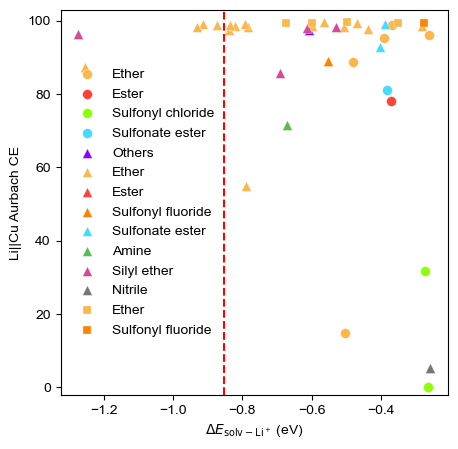

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
# Loop through each unique value and create a scatter plot
c = 0
for db in df_bind_lumo_all__['database_id'].unique():
    # print(db)
    df_db = df_bind_lumo_all__[df_bind_lumo_all__['database_id'] == db]
    for cls in uniq_class_color_comb.keys():
        subset = df_db[df_db['class'].apply(lambda x: cls in x)]
        if len(subset) == 0:
            continue
        ax.scatter(subset['bind_ener_eV'], 100*subset['CE'], label=cls, color=uniq_class_color_comb[cls], marker=shapes[c], edgecolors='white', linewidths=0.25, s=sizes[c])  # Replace 'x_column' and 'y_column' with actual column names
    # df_db_cls = df_db['class'].explode()
    # ax.scatter(subset['bind_ener_eV'], 100*subset['CE'], label=class_, color=uniq_class_color_comb[class_], marker=shapes[c])  # Replace 'x_column' and 'y_column' with actual column names
    c += 1
# plt.title(f'Scatter Plot for {database}')
# ax.vlines(x=-0.328441, ymin=0, ymax=103, color='red', linestyle='--')
ax.vlines(x=df_bind_lumo_all_['bind_ener_eV'][-1:], ymin=-2, ymax=103, color='red', linestyle='--')
ax.set_xlabel('$\Delta E_{\mathrm{solv-Li^+}}$ (eV)')  # Replace with actual label
ax.set_ylabel('Li||Cu Aurbach CE')  # Replace with actual label
ax.set_ylim(-2, 103)
# ax.set_yscale('log')
plt.legend(frameon=False, loc='center left')
plt.savefig('plot_bind_energy_vs_CE_class_010725.eps', dpi=300)
# plt.show()

In [39]:
df_bind_lumo_all_['class'].explode()

0                 Ether
1       Sulfonate ester
2     Sulfonyl chloride
2                 Ether
3     Sulfonyl chloride
4                 Ether
5                 Ester
6                 Ether
7                 Ether
8                 Ether
9                 Ether
10                Ether
11                Ether
12                Ether
13                Ether
14                Ether
15                Ether
16                Ether
17          Silyl ether
18          Silyl ether
19                Ether
19          Silyl ether
20                Ether
21                Ether
22                Ether
23                Ether
24                Ether
25      Sulfonate ester
26      Sulfonate ester
27          Silyl ether
28                Ether
29                Ether
30               Others
31                Ether
32                Ether
32                Amine
33    Sulfonyl fluoride
33                Ether
34                Ester
34              Nitrile
35    Sulfonyl fluoride
36              

In [42]:
subset

,Compound_id,min_config,ID,name,smiles,HOMO_iso,LUMO_iso,Bandgap_iso,CE,salt_conc,database,database_,bind_ener_eV,class,std_smiles,database_id


#### Li||Cu Aurbach CE vs LUMO

In [ ]:
# df_bind_lumo_all_ = pd.read_json('CE_bind_energy_LUMO_all_class_010725.json')
# df_bind_lumo_all__ = df_bind_lumo_all_.iloc[:-1,:] ## remove fsa

In [ ]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
c1 = '#396b3a'
c2 = '#6ea397'
c3 = '#b56171'
c4 = '#79204e'
c5 = '#a5ebcc'
c6 = '#ffd266'
c7 = '#d27672'
c8 = '#46daff'
c9 = '#ffcbcb'
c10 = '#fc8300'
c11 = '#8dff0A'
c12 = '#edff4a'

shapes = ['o', '^', 's']
sizes = [50, 50, 40]

uniq_class_color_comb = {"Others": dark_purple, "Carbonate": c9, "Sulfone": c2, "Ether": orange, "Ester": red, "Sulfoxide": c5, "Sulfonyl fluoride": c10, "Sulfonyl chloride": c11,
                         "Sulfonate ester": c8, "Amine": green, "Amide": blue, "Nitro": c12, "Ketone": pink, "Anhydride": c1, "Imide": anvil, "Silyl ether": purple, 
                         "Phosphate": c4, "Phosphite": c3, "Sulfonamide": c6, "Carbamate": c7, "Nitrile": gray}

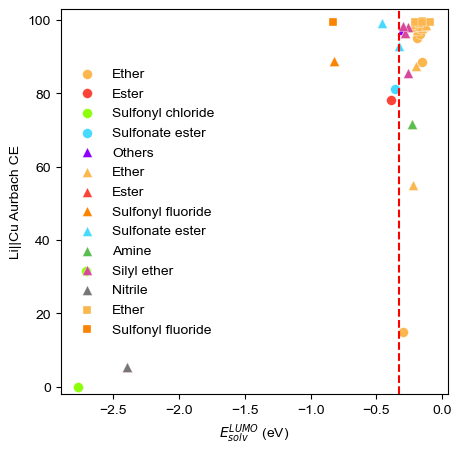

In [60]:
fig, ax = plt.subplots(figsize=(5, 5))
# Loop through each unique value and create a scatter plot
c = 0
for db in df_bind_lumo_all__['database_id'].unique():
    # print(db)
    df_db = df_bind_lumo_all__[df_bind_lumo_all__['database_id'] == db]
    for cls in uniq_class_color_comb.keys():
        subset = df_db[df_db['class'].apply(lambda x: cls in x)]
        if len(subset) == 0:
            continue
        ax.scatter(subset['LUMO_iso'], 100*subset['CE'], label=cls, color=uniq_class_color_comb[cls], marker=shapes[c], edgecolors='white', linewidths=0.25, s=sizes[c])  # Replace 'x_column' and 'y_column' with actual column names
    # df_db_cls = df_db['class'].explode()
    # ax.scatter(subset['bind_ener_eV'], 100*subset['CE'], label=class_, color=uniq_class_color_comb[class_], marker=shapes[c])  # Replace 'x_column' and 'y_column' with actual column names
    c += 1
ax.vlines(x=df_bind_lumo_all_['LUMO_iso'][-1:], ymin=-2, ymax=103, color='red', linestyle='--')
ax.set_xlabel('$E^{LUMO}_{solv}$ (eV)') 
ax.set_ylabel('Li||Cu Aurbach CE') 
ax.set_ylim(-2, 103)
# ax.set_xscale('log')
plt.legend(frameon=False, loc='center left')
plt.savefig('plot_LUMO_vs_CE_class_010725.eps', dpi=300)
# plt.show()